In [65]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np

In [66]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("MachineLearning") \
    .getOrCreate()

In [67]:
df = pd.read_csv('/content/Churn_Modelling.csv')
df = df.drop(['RowNumber'], axis=1)
df

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [68]:
df = spark.read.csv(
    "/content/Churn_Modelling.csv",
    header=True,
    inferSchema=True
)

type(df)


pyspark.sql.classic.dataframe.DataFrame

In [69]:
from pyspark.ml.feature import StringIndexer

geo_indexer = StringIndexer(
    inputCol="Geography",
    outputCol="GeographyIndex"
)

gender_indexer = StringIndexer(
    inputCol="Gender",
    outputCol="GenderIndex"
)

from pyspark.ml.feature import OneHotEncoder

encoder = OneHotEncoder(
    inputCols=["GeographyIndex"],
    outputCols=["GeographyVec"]
)

In [70]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=[
        "CreditScore",
        "GeographyVec",
        "GenderIndex",
        "Age",
        "Tenure",
        "Balance",
        "NumOfProducts",
        "HasCrCard",
        "IsActiveMember",
        "EstimatedSalary"
    ],
    outputCol="features"
)

In [71]:
from pyspark.ml import Pipeline

pipeline = Pipeline(stages=[
    geo_indexer,
    gender_indexer,
    encoder,
    assembler
])

model = pipeline.fit(df)

data = model.transform(df)

data.select("features", "Exited").show(5, truncate=False)

+-----------------------------------------------------------+------+
|features                                                   |Exited|
+-----------------------------------------------------------+------+
|[619.0,1.0,0.0,1.0,42.0,2.0,0.0,1.0,1.0,1.0,101348.88]     |1     |
|[608.0,0.0,0.0,1.0,41.0,1.0,83807.86,1.0,0.0,1.0,112542.58]|0     |
|[502.0,1.0,0.0,1.0,42.0,8.0,159660.8,3.0,1.0,0.0,113931.57]|1     |
|[699.0,1.0,0.0,1.0,39.0,1.0,0.0,2.0,0.0,0.0,93826.63]      |0     |
|[850.0,0.0,0.0,1.0,43.0,2.0,125510.82,1.0,1.0,1.0,79084.1] |0     |
+-----------------------------------------------------------+------+
only showing top 5 rows


In [72]:
train_data, test_data = data.randomSplit([0.8, 0.2], seed=42)

**Decision Tree**



In [73]:
from pyspark.ml.classification import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    labelCol="Exited",
    featuresCol="features",
    maxDepth=5
)

dt_model = dt.fit(train_data)

dt_predictions = dt_model.transform(test_data)



**Random forest:**

In [64]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(
    labelCol="Exited",
    featuresCol="features",
    numTrees=100,
    maxDepth=10
)

rf_model = rf.fit(train_data)

rf_predictions = rf_model.transform(test_data)

In [74]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator = MulticlassClassificationEvaluator(
    labelCol="Exited",
    predictionCol="prediction",
    metricName="accuracy"
)

print("Decision Tree Accuracy:",
      evaluator.evaluate(dt_predictions))

print("Random Forest Accuracy:",
      evaluator.evaluate(rf_predictions))

Decision Tree Accuracy: 0.855804268610099
Random Forest Accuracy: 0.8625715773034878


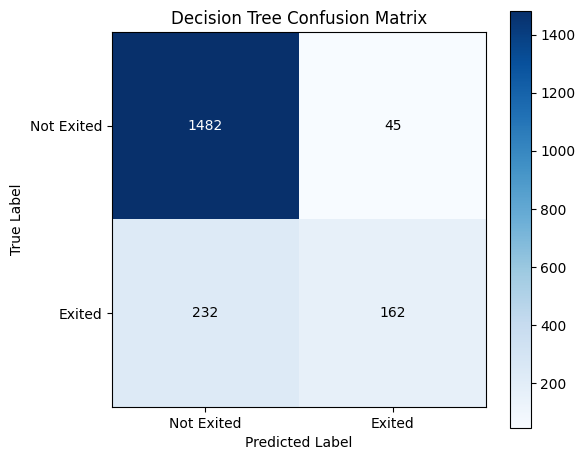

In [75]:
plot_confusion_matrix(dt_predictions,
                      "Decision Tree Confusion Matrix",
                      plt.cm.Blues)

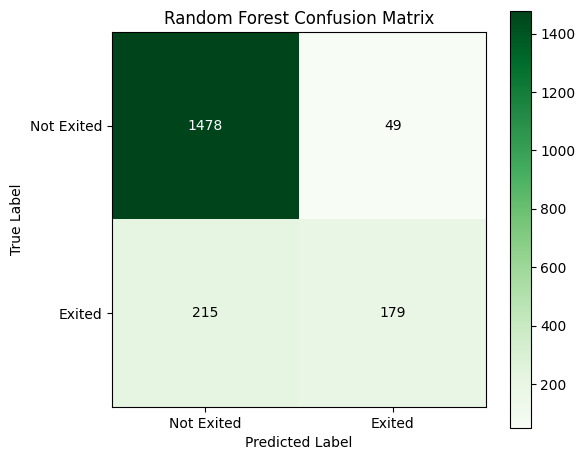

In [76]:
plot_confusion_matrix(rf_predictions,
                      "Random Forest Confusion Matrix",
                      plt.cm.Greens)